In [1]:
%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import sys
from BaselineRemoval import BaselineRemoval
from lmfit.models import LinearModel, LorentzianModel
from ipywidgets import interact, IntSlider

In [182]:
import sys, platform, notebook, ipywidgets

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Jupyter Notebook:", notebook.__version__)
print("ipywidgets:", ipywidgets.__version__)

Python: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
Jupyter Notebook: 6.5.7
ipywidgets: 8.1.7


In [185]:
print(np.__version__)
print(pd.__version__)

1.26.4
2.2.2


In [92]:
## printing versions for readme compatibility
import notebook
import ipywidgets

print("Jupyter Notebook:", notebook.__version__)
print("ipywidgets:", ipywidgets.__version__)

Jupyter Notebook: 6.5.7
ipywidgets: 8.1.7


# mpt_to_df

In [162]:
import re
import numpy as np
import pandas as pd

def mpt_to_df(filename, eis=False):
    with open(filename) as f:
        content = f.readlines()

    n_header_lines = int(re.findall("\d+", content[1])[0])
    column_headers = content[n_header_lines-1].strip("\n").split("\t")[:-1]
    data = np.array([line.strip("\n").split("\t") for line in content[n_header_lines:]], dtype=float)
    if eis == False:
        return pd.DataFrame(data, columns=column_headers)
    else:
        frequencies = np.unique(data[:, 0])
        cycle_id = np.array([item for sublist in [[n]*frequencies.shape[0] for n in range(int(data.shape[0]/frequencies.shape[0]))] 
                             for item in sublist]).reshape(data.shape[0], 1)

        EIS_data_labelled = np.hstack((cycle_id, data))

        column_headers.insert(0, "Cycle id")

        return pd.DataFrame(EIS_data_labelled, columns=column_headers)

# CycVolt

In [168]:
import numpy as np

class cvPeaks(object):
    def __init__(peaks_self, cv, t_step=10, intercept_range=5):
        for key in ["_EH0_capacity_pos", "_EH0_capacity_neg", "EH0_capacity", "_EL0_capacity_pos", "_EL0_capacity_neg", "EL0_capacity"]:
            setattr(peaks_self, key, [])
            
        for hour in range(cv.n_cycles):
            try:
                time_d = cv.discharge.time[hour]
                current_d = cv.discharge.current[hour]
                voltage_d = cv.discharge.voltage[hour]

                dtdt = time_d[1:]-time_d[:-1]
                eis_idx = np.argwhere(dtdt>2*np.nanmedian(dtdt)).flatten()

                if eis_idx.shape[0] > 0:
                    current_d[eis_idx[0]:eis_idx[0]+1] = 0

                dr_idx = np.argwhere(np.sign(current_d)==-1)
                dr_time = time_d[dr_idx]
                dr_current = current_d[dr_idx]
                dr_voltage = voltage_d[dr_idx]

                didv = (current_d[t_step:]-current_d[:-t_step])/(voltage_d[t_step:]-voltage_d[:-t_step])
                v_dv = voltage_d[int(t_step):int(t_step)+didv.shape[0]]

                current_maxima = [[x] for x in range(intercept_range, didv.shape[0]-intercept_range) if 
                     all(np.sign(didv[x-intercept_range:x])==-1) and all(np.sign(didv[x:x+intercept_range])==1)]

                current_maxima_in_range = []
                for m in current_maxima:
                    if m > np.nanmin(dr_idx) and m < np.nanmax(dr_idx):
                        if eis_idx.shape[0] > 0 and m != eis_idx and m != eis_idx+1:
                            current_maxima_in_range.append(m[0])
                        else:
                            current_maxima_in_range.append(m[0])

                EH0_start = np.nanmin(dr_idx.flatten())
                EH0_end = current_maxima_in_range[np.argmin(abs(current_maxima_in_range-EH0_start))]

                EL0_end = np.nanmax(dr_idx.flatten())
                EL0_start = current_maxima_in_range[np.argmin(abs(current_maxima_in_range-EL0_end))]
                EH0_capacity_pos = np.trapz(y=current_d[EH0_start:EH0_end], x=time_d[EH0_start:EH0_end]/60/60)
                EL0_capacity_pos = np.trapz(y=current_d[EL0_start:EL0_end], x=time_d[EL0_start:EL0_end]/60/60)

                ## charge
                current_c = cv.charge.current[hour]
                voltage_c = cv.charge.voltage[hour]
                time_c = cv.charge.time[hour]

                c_EL0_idx = np.arange(np.argmin(abs(voltage_c-voltage_d[EL0_end])), np.argmin(abs(voltage_c-voltage_d[EL0_start])))
                voltage_c_EL0 = voltage_c[c_EL0_idx]
                current_c_EL0 = current_c[c_EL0_idx]
                time_c_EL0 = time_c[c_EL0_idx]

                c_EH0_idx = np.arange(np.argmin(abs(voltage_c-voltage_d[EH0_end])), np.argmin(abs(voltage_c-voltage_d[EH0_start])))
                voltage_c_EH0 = voltage_c[c_EH0_idx]
                current_c_EH0 = current_c[c_EH0_idx]
                time_c_EH0 = time_c[c_EH0_idx]

                c_EL0_neg = np.argwhere(np.sign(current_c_EL0)==-1).flatten()
                c_EH0_neg = np.argwhere(np.sign(current_c_EH0)==-1).flatten()

                EH0_capacity_neg = np.trapz(y=current_c_EH0[c_EH0_neg], x=time_c_EH0[c_EH0_neg]/60/60)
                EL0_capacity_neg = np.trapz(y=current_c_EL0[c_EL0_neg], x=time_c_EL0[c_EL0_neg]/60/60)
        
                peaks_self._EH0_capacity_pos.append(EH0_capacity_pos)
                peaks_self._EH0_capacity_neg.append(EH0_capacity_neg)
                peaks_self.EH0_capacity.append(EH0_capacity_pos-EH0_capacity_neg)

                peaks_self._EL0_capacity_pos.append(EL0_capacity_pos)
                peaks_self._EL0_capacity_neg.append(EL0_capacity_neg)
                peaks_self.EL0_capacity.append(EL0_capacity_pos-EL0_capacity_neg)
            except:
                for key in ["_EH0_capacity_pos", "_EH0_capacity_neg", "EH0_capacity", "_EL0_capacity_pos", "_EL0_capacity_neg", "EL0_capacity"]:
                    vars(peaks_self)[key]


class CycVolt(object):
    def __init__(self, filename, tolerance=0.1):
#         print("Using correct function")
        import re
        with open(filename) as f:
            for line in f.readlines():
                if "dE/dt" in line and "unit" not in line:
                    self.scan_rate = float(re.findall("\d+.\d+", line)[0])
                    
        data = mpt_to_df(filename)
        voltage = np.array(data["Ewe/V"])
        dV = voltage[1:]-voltage[:-1]
        current = np.array(data["<I>/mA"])
        charge_idx = np.argwhere(np.sign(dV)==1).flatten()
        discharge_idx = np.argwhere(np.sign(dV)==-1).flatten()
        time = np.array(data["time/s"])
        
        discharge_ends_WITH_super = [num for n, num in enumerate(discharge_idx[:-1]) if discharge_idx[n+1]-discharge_idx[n]!=1]
        discharge_ends = [num for num in discharge_ends_WITH_super if any([abs(voltage[num+1]-limit)<tolerance for limit in [np.min(voltage), np.max(voltage)]])]
        
        charge_ends_WITH_super = [num for n, num in enumerate(charge_idx[:-1]) if charge_idx[n+1]-charge_idx[n]!=1]
        charge_ends = [0]+[num for num in charge_ends_WITH_super if any([abs(voltage[num+1]-limit)<tolerance for limit in [np.min(voltage), np.max(voltage)]])]
        
        if discharge_ends[-1]>charge_ends[-1]:
            n_cycles = len(discharge_ends)
            charge_ends += [charge_idx[-1]]
        else:
            n_cycles = len(charge_ends)
            discharge_ends += [discharge_idx[-1]]
            
        self.n_cycles = n_cycles
            
        class _State(object):
            def __init__(state_self, state):
                
                ## Patch
                state_self.voltage = []
                state_self.current = []
                state_self.time = []
                ## Patch
                
                if state == "discharge":
                    ## Patch
                    for n in range(len(discharge_ends)):
                        try:
                            state_self.voltage.append(voltage[charge_ends[n]:discharge_ends[n]])
                            state_self.current.append(current[charge_ends[n]:discharge_ends[n]])
                            state_self.time.append(time[charge_ends[n]:discharge_ends[n]])
                        except:
                            print("Failed discharge cycle {}".format(n))
                    ## Patch

#                     state_self.voltage = [voltage[charge_ends[n]:discharge_ends[n]] for n in range(len(discharge_ends))]
#                     state_self.current = [current[charge_ends[n]:discharge_ends[n]] for n in range(len(discharge_ends))]
#                     state_self.time = [time[charge_ends[n]:discharge_ends[n]] for n in range(len(discharge_ends))]
                elif state == "charge":
                    ## Patch
                    for n in range(len(charge_ends)-1):
                        try:
                            state_self.voltage.append(voltage[discharge_ends[n]:charge_ends[n+1]])
                            state_self.current.append(current[discharge_ends[n]:charge_ends[n+1]])
                            state_self.time.append(time[discharge_ends[n]:charge_ends[n+1]])
                        except:
                            print("Failed charge cycle {}".format(n))
                    ## Patch
                
#                     state_self.voltage = [voltage[discharge_ends[n]:charge_ends[n+1]] for n in range(len(charge_ends)-1)]
#                     state_self.current = [current[discharge_ends[n]:charge_ends[n+1]] for n in range(len(charge_ends)-1)]
#                     state_self.time = [time[discharge_ends[n]:charge_ends[n+1]] for n in range(len(charge_ends)-1)]
        setattr(self, "discharge", _State("discharge"))
        setattr(self, "charge", _State("charge"))
        
    def plot_cv(self, figsize=(8, 8), cycles_to_plot="all", cycles_to_skip="none", cmap="tab20", category_cmap=True, reverse_scan_order=True):
        import matplotlib.pyplot as plt
        f, ax = plt.subplots(figsize=figsize)
        
        if cycles_to_plot == "all":
            n_cycles = list(np.arange(0, self.n_cycles))
        else:
            n_cycles = cycles_to_plot
            
        if cycles_to_skip == "none":
            n_cycles = n_cycles
        else:
            n_cycles = [cyc for cyc in n_cycles if cyc not in cycles_to_skip]
        
        if category_cmap==True:
            plot_colors = [vars(plt.cm)[cmap](i) for i in range(len(n_cycles))]
            for ncycle, cycle in enumerate(n_cycles):
                ax.plot([], [], color=plot_colors[ncycle], label=cycle+1)
                ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        else:
            plot_colors = [vars(plt.cm)[cmap](i) for i in range(np.linspace(0, 1, len(n_cycles)))]
            ax.set_position((0.15, 0.15, 0.75, 0.75))
            cbar_ax = f.add_axes((0.8, 0.15, 0.05, 0.6))
            cbar_ticks = np.array([0, 1], dtype=int)
            cmap = plt.cm.get_cmap(cmap)
            norm = mpl.colors.Normalize(vmin=0, vmax=1)
            sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array([])
            cbar = plt.colorbar(sm, ticks=cbar_ticks, cax=cbar_ax)
            cbar.set_label("Cycle number", rotation=90)
            cbar.set_ticks([1, max(n_cycles)])
            cbar.set_ticklabels([1, max(n_cycles)])
            
            
        ax.tick_params(which="both", tickdir="in", right=True, top=True)
        ax.set_xlabel("Potential vs. Li/ Li$^{+}$ (V)")
        ax.set_ylabel("Current (mA)")
        ax.axhline(0, color="k", lw=0.5)
        
        for ncycle, cycle in enumerate(n_cycles):
            if reverse_scan_order == True:
                z_order = self.n_cycles-ncycle
            else:
                z_order = ncycle
            try:
                ax.plot(self.discharge.voltage[cycle], self.discharge.current[cycle], color=plot_colors[ncycle], zorder=z_order)
                ax.plot(self.charge.voltage[cycle], self.charge.current[cycle], color=plot_colors[ncycle], zorder=z_order)
            except:
                continue
                    
#         ax.set_xlim([1.5, 2.8])
        
        plt.tight_layout()
        
        return f, ax
    
    def peak_capacity_ratio(self, t_step=10, intercept_range=5):
        setattr(self, "peak_ratio", cvPeaks(cv=self, t_step=t_step, intercept_range=intercept_range))

# SpectrumMap

In [2]:
"""
Spectrum Map class
Version 2
Last updated: 19/10/2021
Created: 08/10/2021
Added to EigenFit: 06/01/2022
"""

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

class _noise_replace(object):
    """
    Hidden class with attributes for replacing spikes with noise
    ...
    
    Attributes
    ----------
    noise_fill : array
        a short array containing noise within the range of minimum/ maximum values of surrounding signal
        
    start_replace : float
        the index to start replacing data with noise
        
    end_replace : float
        the index to finish replacing data with noise    
    """
    def __init__(self, shift, intensity, spike_pos, smooth_width=10):
        spike_idx = np.argmin(abs(shift-spike_pos))
        ## if near the minimum of the shift axis:
        if spike_idx < 2*smooth_width:
            min_spike = 0
            min_avg = 0
            max_avg = spike_idx+2*smooth_width
            max_spike = spike_idx+smooth_width
        ## if near the maximum of the shift axis:
        elif shift.shape[0]-spike_idx < 2*smooth_width:
            min_spike = spike_idx-smooth_width
            min_avg = spike_idx-2*smooth_width
            max_avg = shift.shape[0]
            max_spike = shift.shape[0]
        else:
            min_spike = spike_idx-smooth_width
            min_avg = spike_idx-2*smooth_width
            max_avg = spike_idx+2*smooth_width
            max_spike = spike_idx+smooth_width

        noise_min = np.nanmin([np.nanmin(intensity[min_avg:min_spike]),
                      np.nanmin(intensity[max_spike:max_avg])])

        noise_max = np.nanmax([np.nanmax(intensity[min_avg:min_spike]),
                      np.nanmax(intensity[max_spike:max_avg])])

        self.noise_fill = np.random.rand(2*smooth_width)*(noise_max-noise_min)+noise_min
        self.start_replace = min_spike
        self.end_replace = max_spike
        
def CRE_single(shift, intensity, spike_pos, smooth_width=10):
    """
    Function to repair a single spectrum with a cosmic ray spike at a user-defined position
    
        Parameters:
            shift (array): The shift/ x-axis for the data to be repaired
            intensity (array): The intensity/ y values of the data to be repaired
            spike_pos (float): The shift value at which the cosmic ray occurs
            smooth_width (int) (default = 10): The number of shift values to replace by noise
    """
    repaired = np.zeros((intensity.shape))
    
    if type(spike_pos)==list:
        replacements = [_noise_replace(shift=shift, intensity=intensity, spike_pos=pos, smooth_width=smooth_width) \
                        for pos in spike_pos]
        replacement_idx = np.array([np.arange(replacement.start_replace, replacement.end_replace) for replacement in replacements])
        
        for x in range(intensity.shape[0]):
            if x not in replacement_idx:
                repaired[x] = intensity[x]
                
        for rp in replacements:
            repaired[rp.start_replace:rp.end_replace] = rp.noise_fill
            repaired[:rp.start_replace] = intensity[:rp.start_replace]
            repaired[rp.end_replace:] = intensity[rp.end_replace:]

    if type(spike_pos) == float or type(spike_pos) == int:
        rp = _noise_replace(shift=shift, intensity=intensity, spike_pos=spike_pos, smooth_width=smooth_width)
        repaired[rp.start_replace:rp.end_replace] = rp.noise_fill
        repaired[:rp.start_replace] = intensity[:rp.start_replace]
        repaired[rp.end_replace:] = intensity[rp.end_replace:]
    
    return np.vstack((shift, repaired)).T


class _Map(object):
    """
    Hidden container class
    ...
    Attributes
    ----------
    shift: array
        The shift (x) axis
   shift_extent: int
        The length of the shift axis array
   map: array
        The Raman map data with size (x_extent, y_extent, shift_extent)
    """
    def __init__(self, shift, map_data):
        self.shift = shift
        self.shift_extent = shift.shape[0]
        self.map = map_data
        
        
class SpectrumMap(object):
    """
    A class to contain Raman map data, with associated pre-processing and display functions
    ...
    Input arguments
    ----------
    filename: str
        name and path of the four-column text file of Raman map data, including file extension
    Attributes
    ----------
    x_coords: numpy array
        x positions corresponding to spectra positions
    y_coords: numpy array
        y positions corresponding to spectra positions
    x_extent: int
        number of x positions at which spectra were collected
    y_extent: int
        number of y positions at which spectra were collected
        
    Subclass (_Map) for raw data: 
    raw.shift: numpy array
        the Raman shift axis corresponding to the map data
    raw.shift_extent: int
        number of shift values
    raw.map: numpy array
        3d array containing the map data (dimensions for x, y, and shift axes)
        
    Methods
    ----------
    slide_viewer(xmin=None, ymin=None):
        returns an interactive (ipywidgets) plot of the signal
        
    fix_cosmic_ray(x_pos, y_pos, spike_pos, smooth_width=10):
        repairs cosmic rays at user-defined x_pos, y_pos map positions at shift value spike_pos. 
        corrects values directly in all _Map subclasses (raw, plus ccd and clipped if created)
        returns none
    
    set_CCD_remove(pixel_position, smooth_width=10):
        removes a spike located at the same shift value (i.e. pixel position) throughout a map
        returns 'ccd' as new attribute of SpectrumMap (_Map class with shift, shift_extent, and map attributes)
        
    set_clip_range(start_shift=None, end_shift=None):
        returns 'clipped' as a new attribute of SpectrumMap (_Map class with shift, shift_extent, and map attributes)
        
    Notes
    ----------
    
     To instantiate the class, use:
            s = SpectrumMap(filename)
    The data will be accessible using:
    s.raw.map
    To view the data, use:
        s.slide_viewer()
    To remove cosmic rays, use:
        s.fix_cosmic_ray(x_pos, y_pos, spike_pos)
    To remove a consistent spike (from a dead CCD pixel), use:
        s.set_CCD_remove(pixel_position)
        The fixed data will be accessible using:
        s.ccd.map
        NB: fix the spike before clipping the data range
    To clip the range of data to view, use:
        s.set_clip_range(start_shift, end_shift)
        The clipped data will be accessible using:
        s.clipped.map
    """
    
    def __init__(self, data_file):
        raw_data = np.loadtxt(data_file)
        self.x_coords = np.array(np.unique(raw_data[:, 0]), dtype=int)
        self.y_coords = np.array(np.unique(raw_data[:, 1]), dtype=int)
        raw_shift, raw_shift_locs = np.unique(raw_data[:, 2], return_index=True)
        
        self.x_extent = self.x_coords.shape[0]
        self.y_extent = self.y_coords.shape[0]        
        
        raw_shift_extent = raw_shift.shape[0]
        raw_map = np.zeros((self.x_extent, self.y_extent, raw_shift_extent))
        for nx, x in enumerate(self.x_coords):
            for ny, y in enumerate(self.y_coords):
                spectrum = raw_data[np.nonzero((raw_data[:, 0] == x) & (raw_data[:, 1] == y)), -1].flatten()
                raw_map[nx, ny, :] = spectrum[::-1] 
                
        setattr(self, "raw", _Map(shift=raw_shift, map_data=raw_map))
        
    def set_CCD_remove(self, pixel_position, smooth_width=10):
        """
        Removes a spike at a constant shift value at every (x, y) position in a Raman map, for example due to a faulty pixel on a CCD device
        
            Parameters:
                pixel_position (float): The shift value at which the spike occurs
                smooth_width (int, default=10): The number of shift values to be replaced by random noise each side of the spike
                
            Returns:
                self.ccd (object): A _Map class with shift, shift_extent, and map attributes
        """
        pixel_idx = np.argmin(abs(self.raw.shift-pixel_position))               
        CCD_map = np.zeros((self.x_extent, self.y_extent, self.raw.shift_extent))
        
        for x in range(self.x_extent):
            for y in range(self.y_extent):
                pre_max = np.nanmax(self.raw.map[x, y, pixel_idx-2*smooth_width:pixel_idx-smooth_width])
                post_max = np.nanmax(self.raw.map[x, y, pixel_idx+smooth_width:pixel_idx+2*smooth_width])
                pre_min = np.nanmin(self.raw.map[x, y, pixel_idx-2*smooth_width:pixel_idx-smooth_width])
                post_min = np.nanmin(self.raw.map[x, y, pixel_idx+smooth_width:pixel_idx+2*smooth_width])
                
                noise_fill = min([pre_min, post_min])+(max([pre_max, post_max])-min([pre_min, post_min]))*np.random.rand(2*smooth_width)
                
                CCD_map[x, y, :pixel_idx-smooth_width] = self.raw.map[x, y, :pixel_idx-smooth_width]              
                CCD_map[x, y, pixel_idx-smooth_width:pixel_idx+smooth_width] = noise_fill
                CCD_map[x, y, pixel_idx+smooth_width:] = self.raw.map[x, y, pixel_idx+smooth_width:] 
                
        setattr(self, "ccd", _Map(shift=self.raw.shift, map_data=CCD_map))
        
    def set_clip_range(self, start_shift=None, end_shift=None):
        """
        Returns a map with x_extent and y_extent corresponding to raw data, with a range of shift values corresponding to a region of interest defined by the user
        
            Parameters:
                start_shift (float, default=None): The shift value corresponding to the lower bound of the region of interest.
                                                   If 'None', uses the first shift value in the data
                end_shift (float, default=None): The shift value corresponding to the upper bound of the region of interest.
                                                 If 'None', uses the last shift value in the data
        """
        if start_shift == None:
            start_shift = min(self.raw.shift)
        if end_shift == None:
            end_shift = max(self.raw.shift)
        start_idx = np.argmin(abs(self.raw.shift-start_shift))
        end_idx = np.argmin(abs(self.raw.shift-end_shift))
                
        if "ccd" in vars(self).keys():
            setattr(self, "clipped", _Map(shift=self.raw.shift[start_idx:end_idx],
                                          map_data=self.ccd.map[:, :, start_idx:end_idx]))
        else:
            setattr(self, "clipped", _Map(shift=self.raw.shift[start_idx:end_idx],
                                          map_data=self.raw.map[:, :, start_idx:end_idx]))
    
    def fix_cosmic_ray(self, x_pos, y_pos, spike_pos, smooth_width=10):
        """
        Repairs cosmic rays identified by the user and applies repairs to "raw", AND "ccd", AND "clipped" maps if defined. 
        
            Parameters:
                x_pos (int): the x position of the spectrum to repair within the SpectrumMap map
                y_pos (int): the y position of the spectrum to repair within the SpectrumMap map
                spike_pos (float): the shift value at which the spike occurs
                smooth_width (int, default=10): the number of shift positions either side of the spike to replace with noise
        
        """
        maps_to_fix = [key for key in vars(self).keys() if key in ["raw", "ccd", "clipped"]]
        
        for processed in maps_to_fix:
            if spike_pos < max(vars(self)[processed].shift) and spike_pos > min(vars(self)[processed].shift):
                vars(self)[processed].map[x_pos, y_pos, :] = CRE_single(shift=vars(self)[processed].shift,
                                                                       intensity=vars(self)[processed].map[x_pos, y_pos, :],
                                                                       spike_pos=spike_pos,
                                                                       smooth_width=smooth_width)[:, 1]
    def slide_viewer(self, display="raw"):
        """
        Returns an ipywidgets controlled interactive graph display, with widgets to control x and y position of spectrum to display
            
            Parameters:
                display (str): one of "raw", "clipped", or "ccd"
                               selects the (pre-processed) data to display
        """
        f, ax = plt.subplots()
        shift = vars(self)[display].shift
        map_data = vars(self)[display].map
        
        spectrum, = ax.plot(shift, map_data[0, 0, :])
        
        ax.tick_params(which="both", tickdir="in", right=True, top=True)
        ax.set_xlabel("Raman shift (cm$^{-1}$)")
        ax.set_ylabel("Intensity (a.u.)")
        
        def update(x, y):
            spectrum.set_ydata(map_data[x, y, :])
            ax.set_ylim([0.9*min(map_data[x, y, :]),
                         1.1*max(map_data[x, y, :])])

        
        interact(update, x=IntSlider(min=0, max=self.x_extent-1, step=1),
                         y=IntSlider(min=0, max=self.y_extent-1, step=1))

# MapSeries
## _SimpleLoad

In [3]:
### Previously named LoadReload
## Moved to EigenFit 06/01/2022 and combined with _SimpleLoad
## 06/01/2022:
### Generalised to get_sequence_id and MapSeries, with changeable argument to search for (sequence label) rather than always specified as "cellvoltage"
## 02/02/2022
### Removed tqdm loadbar from verbose=False in update method
### Set "voltage" as default keyword for series_by in _SimpleLoad and MapSeries
### Added x_coords and y_coords to _Common and _find_common

## 05/02/2022
## Added quick_stack_view method

## 03/03/2022
## Added cosmic_ray_view method
## Added docstrings

import os
import numpy as np

import re
import glob
try:
    from tqdm import notebook
    from notebook import tqdm as notebook
except:
    from tqdm import tqdm_notebook as notebook
    
def get_sequence_id(fname, sequence_label="cellvoltage"):
    import re
    return [float(re.findall("\d+.\d+", seg)[0]) for seg in os.path.split(fname)[-1].split("_") if sequence_label in seg][0]

class _Common(object):
    def __init__(self):
        attrs = ["x_extent", "y_extent", "shift", "shift_extent", "x_coords", "y_coords"]
        self.__dict__.update([(key, None) for key in attrs])

class _SimpleLoad(object):
    def __init__(self, path, verbose=False, sequence_label="cellvoltage", fname_delimiter="_", series_by="voltage", sort=True):
        """
        path = directory containing data files for sequence of measurements
        verbose = show tqdm loading bar if True
        sequence_label = string within filename indicating wich substring to use to label items in sequence
        fname_delimiter = filenames with multiple substrings can be split by delimiter
        series_by = e.g. time series, voltage series. The dimension in which the measurement series changes.
        """
        self._path = path
        self._sort = sort
        self.common = _Common()
        
        if verbose == True:
            self.data = dict([(get_sequence_id(fname, sequence_label), SpectrumMap(fname))\
                               for fname in notebook(glob.glob(os.path.join(path, "*.txt")))
                              ])
        elif verbose == False:
            self.data = dict([(get_sequence_id(fname, sequence_label), SpectrumMap(fname))\
                               for fname in glob.glob(os.path.join(path, "*.txt"))
                              ])
        if series_by is None:
            self._series_by = "series"
        else:
            self._series_by = series_by
        self._sequence_label= sequence_label
        setattr(self, self._series_by, [*self.data.keys()])
        self._find_common()
        
    def update(self, verbose=False):
        """
        Updates the MapSeries with any new data in the load_path directory.
        Useful if updating MapSeries on the fly (while adding new .txt files to the directory) and re-sorts series labels from lowest to highest if sort=True
        Inputs
        ---------
        verbose (bool) default=False:
            displays a loading bar if True
        """
        previous_keys = [*self.data.keys()]
        if verbose == True:
            self.data.update([(get_sequence_id(fname, self._sequence_label), SpectrumMap(fname))\
                               for fname in notebook(glob.glob(os.path.join(self._path, "*.txt")))
                              if get_sequence_id(fname, self._sequence_label) not in self.data.keys()])
        elif verbose == False:
            self.data.update([(get_sequence_id(fname, self._sequence_label), SpectrumMap(fname))\
                               for fname in glob.glob(os.path.join(self._path, "*.txt"))
                              if get_sequence_id(fname, self._sequence_label) not in self.data.keys()])            
        
        if self._sort == True:
            self.data = dict([(key, self.data[key]) for key in np.sort([*self.data.keys()])])
        vars(self)[self._series_by] = [*self.data.keys()]
         
        updated_keys = [name for name in [*self.data.keys()] if name not in previous_keys]
        if verbose == True:
            print("Previous keys: \n {}".format(previous_keys))
            print("New keys: \n {}".format(updated_keys))   
        self._find_common()
        
    def _find_common(self, clipped=False):
        """
        hidden utility for updating the common values
        """
        if "common" not in vars(self):
            self.common = _Common()
            
        for key in ["x_coords", "y_coords"]:
            vars(self.common)[key] = vars([*self.data.values()][0])[key]

        for key in ["x_extent", "y_extent"]:      
            if np.unique([vars(meas)[key] for meas in self.data.values()]).shape[0] == 1:
                vars(self.common)[key] = vars([*self.data.values()][0])[key]
            else:
                vars(self.common)[key] = None
                
        for key in ["shift", "shift_extent"]:
            if clipped==True:
                vars(self.common)[key] = vars([*self.data.values()][0].clipped)[key]
            else:
                vars(self.common)[key] = vars([*self.data.values()][0].raw)[key]
        
    def set_clip_range(self, start_shift=None, end_shift=None):
        """
        select a sub-set of data within a range of shift values for further analyis (applied to all map data in series simultaneously)
        
        Inputs
        ----------
        start_shift (float) default=None:
            Lowest shift value to include in the sub-set (uses first measured value if None)
        end_shift (float) default=None:
            Highest shift value to include in the sub-set (uses last measured value if None)
        """
        for key, measurement in self.data.items():
            measurement.set_clip_range(start_shift, end_shift)
 
## Move process to dimension reduction 
#         clipped_ranges = [measurement.clipped.map.shape[-1] for measurement in self.data.values()]
#         for key, measurement in self.data.items():
#             measurement.clipped.map = measurement.clipped.map[:, :, :np.nanmin(clipped_ranges)]
#         print("using correct code")
            
        self._find_common(clipped=True)  
        
        
    def quick_stack_view(self, offset_max=100):
        """
        view a graph of the spectra, labelled by series value, with interactive sliders to select the (x, y) map position to show
        """
        
        import matplotlib.pyplot as plt
        import numpy as np
        from ipywidgets import interact, IntSlider, FloatSlider
        f, ax = plt.subplots()
        def update(x, y, offset):
            ax.cla()
            ax.set_prop_cycle("color", [plt.cm.viridis(i) for i in np.linspace(0, 1, len(self.voltage))])

            try:
                [ax.plot(self.common.shift, 
                         self.data[volt].clipped.map[x, y, :]+offset*(len(self.voltage)-nvolt),
                         label=volt) for nvolt, volt in enumerate(self.voltage)];
            except:
                [ax.plot(self.common.shift, 
                         self.data[volt].raw.map[x, y, :]+offset*(len(self.voltage)-nvolt),
                         label=volt) for nvolt, volt in enumerate(self.voltage)];

            ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
            ax.tick_params(which="both", tickdir="in", right=True, top=True)
            ax.set_xlabel("Raman shift (cm$^{-1}$)")
            ax.set_ylabel("Intensity (a.u.)")
            plt.tight_layout()
            ax.set_position((0.15, 0.15, 0.7, 0.7))
        interact(update, x=IntSlider(min=0, max=self.common.x_extent-1, step=1), y=IntSlider(min=0, max=self.common.y_extent-1),
                offset=IntSlider(min=0, max=offset_max, value=40, step=10))

        return f, ax
    
    def cosmic_ray_view(self, positions_to_view=3,
                        show_all_voltages=True, voltages_to_show=None, first_n=False, last_n=False, n_voltages=2,
                        colors=8, mark_interval=4,
                        figsize=(6, 6)
                       ):
        """
        View a 'stack' of graphs with data for some/ all of the series values with interactive sliders for quick manual identification of cosmic ray spikes. 
        Inputs
        ----------
        positions_to_view (int) default=3:
            the number of axes to show in the vertical stack of plots
        
        show_all_voltages (bool) default=True:
            if True, displays all of the series spectra for each position
            if False, set first_n or last_n to True (see below) or specify voltages_to_show as list
            
        voltages_to_show (list) default=None:
            if show_all_voltages is False, specify a list of series values to show        
        
        first_n (bool) default=False:
            if True, displays the first n_voltages (show_all_voltages=False)
        
        last_n (bool) default=False:
            if True, displays the first n_voltages (show_all_voltages=False)
        
        n_voltages (int) default=2:
            the number of voltages (first_n or last_n) to display
        
        colors (int) default=8:
            the number of different colors to use to display voltages (NB plots also differentiated by markers)
        
        mark_interval (int) default=4:
            interval between markers. Set to 1 to mark every point (takes longer for graph to load)
        
        figsize (tuple) default=(6, 6):
            size of the matplotlib figure
        """
        
        import matplotlib.pyplot as plt
        import numpy as np
        from ipywidgets import interact, IntSlider, FloatSlider
        n_segments = int(np.ceil(self.common.x_extent/positions_to_view))

        if first_n == True:
            voltages_to_plot = self.voltage[:n_voltages]
        if last_n == True:
            voltages_to_plot = self.voltage[-n_voltages:]
        elif show_all_voltages == True:
            voltages_to_plot = self.voltage

        ax_sort = dict([(n, 
                     np.arange(self.common.x_extent)[positions_to_view*n:positions_to_view*(n+1)]) 
                        for n in range(n_segments)])

        if "clipped" in vars([*self.data.values()][0]):
            disp = "clipped"
        else:
            disp = "raw"

        markers = ["o", "s", "d", "^", "v"]
        colors = [plt.cm.tab10(i) for i in range(colors)]

        color_id = 0
        marker_id = 0
        plot_colors = []
        plot_markers = []

        for nv, v in enumerate(voltages_to_plot):
            if color_id < len(colors):
                plot_colors.append(colors[color_id])
                plot_markers.append(markers[marker_id])
                color_id += 1
            elif color_id == len(colors):   
                color_id = 0
                marker_id += 1
                plot_colors.append(colors[color_id])
                plot_markers.append(markers[marker_id])  

        f, (axes) = plt.subplots(positions_to_view, 1, figsize=(figsize))

        for axis in axes:
            pos = axis.get_position()
            axis.set_position((pos.x0, pos.y0+0.05, 0.8*pos.width, pos.height))

        def update(seg_id, x):
            for row in range(positions_to_view):
                axes[row].cla()
            for row in range(positions_to_view):
                try:
                    axes[row].set_ylabel("x={}, y={}".format(x, ax_sort[seg_id][row]))
                    [axes[row].plot(self.common.shift, 
                                    vars(self.data[volt])[disp].map[x, ax_sort[seg_id][row], :],
                                    marker=plot_markers[nvolt],
                                    markevery=4,
                                    label=volt) for nvolt, volt in enumerate(voltages_to_plot)];
                except:
                    pass

            handles, labels = axes[0].get_legend_handles_labels()
            f.legend(handles, labels, loc="center left", bbox_to_anchor=(0.8, 0.5))
        interact(update, seg_id=IntSlider(min=0, max=n_segments-1, step=1),
                         x=IntSlider(min=0, max=self.common.x_extent-1, step=1))

        return f, (axes)
    

## _MapSeries

In [9]:
def MapSeries(load_path, verbose=False,
              sequence_label="cellvoltage", fname_delimiter="_",
              series_by="voltage", sort=True):
    """
    Creates, loads, or updates a series of Raman maps sorted by a series label, and includes functions for pre-processing and viewing the raw data prior to fitting.
    
    Inputs
    ----------
    load_path (str):
        path to a directory containing text files to load into a map series (possibly with pre-created VoltageSeries.npy file)
    verbose (bool) default = False:
        displays a loading bar if True
    sequence_label (str) default = "cellvoltage":
        the label used in filenames to indicate the substring containing the series value
    fname_delimiter (str) default = "_"
        character used to separate filename into substrings to find label
    series_by (str) default = "voltage"
        the label given to the list of series values in the MapSeries object
    sort (bool) default = True
        sort the data series from lowest to highest
        
    Methods
    ----------
    update:
        appends new data files
    set_clip_range:
        select a sub-set of the shift axis values
    quick_stack_view:
        displays all the spectra measured at the same position for the full series
    cosmic_ray_view:
        displays multiple spectra at a given position with multiple plots for quick identification of cosmic rays
    
    
    Before you start: 
    ----------
    Save the raw Raman data for a series (e.g. time series, voltage series) into a single directory. The filename can be anything, but should include a 'sequence label' and corresponding value delimited by a recognisable character (typically '_')
    
    Example filenames: 'myRamanMap_cellvoltage2.45_514nm_center750.txt' -- sequence_label="cellvoltage", fname_delimiter="_"
                       'myRamanMap-timestamp60secs-514nm.txt" -- sequence_label="timestamp", fname_delimiter="-"
                       
   How to call:
   ----------
   series = MapSeries(load_path=os.path.join("Top_directory", "Series_directory"))
   
   Notes:
   ----------                       
   Creating a MapSeries automatically saves the corresponding formatted data in a .npy file in the load_path directory. 
   New data can be incorporated into a MapSeries object by simply calling the MapSeries function with the load_path specified: this will append new data to the existing .npy file. (This saves time compared to reloading all of the data fresh every time the function is called). 
   Returns _SimpleLoad class (with methods described in this docstring)
                       
    """  
    try: ## Back-up plan added 25/01/2026 for compatibility
        if "VoltageSeries.npy" in os.listdir(load_path):
            if verbose == True:
                print("Reloading previous SimpleLoad object")            
            reload = np.load(os.path.join(load_path, "VoltageSeries.npy"), allow_pickle=True).item()
            reload.update(verbose=verbose)
            np.save(os.path.join(load_path, "VoltageSeries.npy"), reload, allow_pickle=True)        
            return reload
            pass
        else:        
            if verbose == True:
                print("Making new SimpleLoad object")
            load = _SimpleLoad(os.path.join(load_path), series_by=series_by, sequence_label=sequence_label, verbose=verbose)
            np.save(os.path.join(load_path, "VoltageSeries.npy"), load, allow_pickle=True)
            return load
    except:
        print("Making new SimpleLoad object")
        load = _SimpleLoad(os.path.join(load_path), series_by=series_by, sequence_label=sequence_label, verbose=verbose)
        np.save(os.path.join(load_path, "VoltageSeries.npy"), load, allow_pickle=True)
        return load

# DimensionReduction

In [20]:
import numpy as np
### https://github.com/nevernervous78/nirpyresearch/blob/master/snippets/Scatter_corrections_techniques.ipynb

def snv(input_data):
    # Define a new array and populate it with the corrected data  
    output_data = np.zeros_like(input_data)
    for i in range(input_data.shape[0]):
        # Apply correction
        output_data[i,:] = (input_data[i,:] - np.mean(input_data[i,:])) / np.std(input_data[i,:])

    return output_data

In [56]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

try:
    from tqdm import notebook
    from notebook import tqdm as notebook
except:
    from tqdm import tqdm_notebook as notebook
    
from BaselineRemoval import BaselineRemoval

from sklearn.decomposition import PCA


from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)

class DimensionReduction(object):
    def __init__(self, SpectrumMap_object):       
        try:
            map_reshaped = SpectrumMap_object.clipped.map.reshape(SpectrumMap_object.x_extent*SpectrumMap_object.y_extent,
                                                   SpectrumMap_object.clipped.shift_extent)
            self.shift = SpectrumMap_object.clipped.shift
        except:
            map_reshaped = SpectrumMap_object.raw.map.reshape(SpectrumMap_object.x_extent*SpectrumMap_object.y_extent,
                                               SpectrumMap_object.raw.shift_extent)
            self.shift = SpectrumMap_object.raw.shift
            
        self.background_removed = np.array([BaselineRemoval(spectrum).IModPoly(4) for spectrum in notebook(map_reshaped)])
        self.normalised = snv(self.background_removed)
        
    def perform_pca(self, n_components):
        self.n_components = n_components
        self.pca = PCA(n_components=None)
        self.fit_transform = self.pca.fit_transform(self.normalised)
        self.components = self.pca.components_
        self.data_reduced = np.dot(self.normalised,
                                   self.components[:n_components, :].T)
        self.data_reconstructed = np.dot(self.data_reduced,
                                        self.components[:n_components, :])
    def visualise_components(self, components_to_display=3):
        f, ax = plt.subplots()
        [ax.plot(self.shift, self.components[i]+0.3*(components_to_display-i)) for i in range(components_to_display)];
        [ax.axhline(0.3*(components_to_display-i), color="k", lw=0.5) for i in range(components_to_display)];
        return f, ax
        

class SeriesDimensionReduction(object):
    def __init__(self, MapSeries_object, reload_path="none", background_degree=4):
        self.common = MapSeries_object.common
        self._MapSeries = MapSeries_object
        self._series_label = MapSeries_object._series_by
        setattr(self, self._series_label, vars(MapSeries_object)[MapSeries_object._series_by])
        
        if reload_path != "none" and os.path.isdir(reload_path) == False:
            os.makedirs(reload_path)
        
        if reload_path == "none" or "background_removed_degree_{}.npy".format(background_degree) not in os.listdir(reload_path):      
            map_reshaped = {}
            self.background_removed = {}
            for idx in notebook(vars(self)[self._series_label]):    ### equivalent to each voltage
                
                try:
                    map_reshaped.update([(idx, 
                                          MapSeries_object.data[idx].clipped.map.reshape(self.common.x_extent*self.common.y_extent, 
                                                                                    MapSeries_object.data[idx].clipped.shift_extent))])
                except:
                    map_reshaped.update([(idx, MapSeries_object.data[idx].raw.map.reshape(self.common.x_extent*self.common.y_extent, 
                                                                              MapSeries_object.data[idx].raw.shift_extent))])                 
                
                self.background_removed.update([(idx,
                                                  np.array([BaselineRemoval(spectrum).IModPoly(background_degree) for\
                                                            spectrum in map_reshaped[idx]]))
                                               ])
                
                if reload_path != "none":
                    np.save(os.path.join(reload_path, "background_removed_degree_{}.npy".format(background_degree)),
                            self.background_removed,
                           allow_pickle=True)
        else:
            map_reshaped = {}

            self.background_removed = np.load(os.path.join(reload_path, "background_removed_degree_{}.npy".format(background_degree)),
                            allow_pickle=True).item()
            for idx in vars(self)[self._series_label]:    ### equivalent to each voltage
                if idx not in self.background_removed.keys():
                    try:
                        map_reshaped.update([(idx, 
                                              MapSeries_object.data[idx].clipped.map.reshape(self.common.x_extent*self.common.y_extent, 
                                                                                        MapSeries_object.data[idx].clipped.shift_extent))])
                    except:
                        map_reshaped.update([(idx, MapSeries_object.data[idx].raw.map.reshape(self.common.x_extent*self.common.y_extent, 
                                                                                  MapSeries_object.data[idx].raw.shift_extent))])                 

                    self.background_removed.update([(idx,
                                                      np.array([BaselineRemoval(spectrum).IModPoly(background_degree) for\
                                                                spectrum in map_reshaped[idx]]))
                                                   ])       
            np.save(os.path.join(reload_path, "background_removed_degree_{}.npy".format(background_degree)),
                                self.background_removed,
                               allow_pickle=True)
        
        min_shift_length = min([[*self.background_removed.values()][i].shape[1] for i in range(len(self.background_removed))])
        self._min_shift_length = min_shift_length
        
        combined_bkg_rem = np.array([*self.background_removed.values()])[:, :, :self._min_shift_length]
        combined_data = combined_bkg_rem.reshape((len(self.background_removed)*self.common.x_extent*self.common.y_extent,
                          self.common.shift_extent))
        
#         combined_data = np.vstack((np.array([*self.background_removed.values()][i][:, :min_shift_length])) for i in range(len(self.background_removed)))
        normalised_data = snv(combined_data)
        
        self.normalised = dict([(idx,
                                 normalised_data[n_idx*(self.common.x_extent*self.common.y_extent): 
                                                 (n_idx+1)*(self.common.x_extent*self.common.y_extent)])
                               for n_idx, idx in enumerate(vars(self)[self._series_label])
                               ])
        
    def perform_pca(self, n_components=None):
        self.pca = dict([(idx, PCA(n_components=None)) for idx in (vars(self)[self._series_label])]) ## n_components used defined manually later
        self.n_components = n_components
        self.fit_transformed = dict([(idx, self.pca[idx].fit_transform(self.normalised[idx]))
                                     for idx in self.pca.keys()])
        
        self.components = dict([(idx, self.pca[idx].components_) for idx in self.pca.keys()])
        self.inverse_tranformed = dict([(idx, 
                                         self.pca[idx].inverse_transform(self.fit_transformed[idx])) for idx in self.pca.keys()])
        self.data_reduced = dict([(idx,
                                   np.dot(self.normalised[idx],
                                          self.components[idx][:n_components, :].T))
                                  for idx in self.pca.keys()])
        self.data_reconstructed = dict([(idx,
                                         np.dot(self.data_reduced[idx], self.components[idx][:n_components, :]))
                                        for idx in self.pca.keys()])
    
    def visualise_components(self, components_to_display=3):   
        f, ax = plt.subplots()
    
        def update(v_idx, offset):
            ax.cla()
            voltage = [*(vars(self)[self._series_label])][v_idx]
            ax.set_title(" {} V".format(voltage))
            ax.tick_params(which="both", tickdir="in", top=True, right=True)
            ax.set_yticks([])
            ax.set_xlabel("Raman shift (cm$^{-1}$)")
            [ax.plot(self.common.shift, self.components[voltage][i, :]+(components_to_display-i)*offset) for i in range(components_to_display)];
            [ax.text(x=np.max(self.common.shift), y=(components_to_display-i)*offset, s="PC {}".format(i+1), ha="right") for i in range(components_to_display)];
            [ax.axhline((components_to_display-i)*offset, color="k", lw=0.5) for i in range(components_to_display)];
            ax.xaxis.set_major_locator(MultipleLocator(200))
            ax.xaxis.set_minor_locator(MultipleLocator(20))
        interact(update, v_idx=IntSlider(min=0, max=len((vars(self)[self._series_label]))-1, step=1),
                offset=FloatSlider(min=0, max=1, step=0.05, value=0.3))
        return f, ax

# SelectPeaks

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

import ipywidgets as wg

class SelectPeaks(object):
    def __init__(self, voltage_series, peaks_to_fit=[152, 202, 218, 248, 398, 438, 450, 473, 504, 745], reload=False):
        layout = layout=wg.Layout(flex="1 1 0%", width="auto")
        
        if reload!=False:
            self._previous_values = np.load(reload, allow_pickle=True).item()
        else:
            self._previous_values = dict([(volt,
                                     dict([(peak, False) for peak in peaks_to_fit])) for volt in voltage_series
                                   ])
        self._checkbox_dict = {}
        self._voltages = voltage_series
        self._peaks = peaks_to_fit
        
        for volt in voltage_series:
            self._checkbox_dict.update([(volt, {})])
            if volt in self._previous_values.keys():
                for peak in peaks_to_fit:
                    if peak in self._previous_values[volt].keys():
                        self._checkbox_dict[volt].update([(peak, wg.Checkbox(indent=False, value=self._previous_values[volt][peak], layout=layout))])
                    else:
                        self._checkbox_dict[volt].update([(peak, wg.Checkbox(indent=False, value=False, layout=layout))])
            else:
                for peak in peaks_to_fit:
                    self._checkbox_dict[volt].update([(peak, wg.Checkbox(indent=False, value=False, layout=layout))])
        
        self.grid = wg.HBox([wg.VBox([wg.Label(value=str(peak)) for peak in [" "]+[*self._checkbox_dict[volt].keys()]])]+\
                            [wg.VBox([wg.Label(value=str(volt))]+[*self._checkbox_dict[volt].values()]) for volt in voltage_series])
    def get_checkbox_values(self, save_name=None, save_path=None):
        if save_path == None or os.path.isdir(save_path)==False:
            try:
                os.mkdir("selected_peaks")
            except:
                pass
            save_path = "selected_peaks"
        
        self.saved_values = dict([(float(self.grid.children[nvolt].children[0].value),
                         dict([(int(peak), self.grid.children[nvolt].children[npeak+1].value) for npeak, peak in enumerate([label.value for label in self.grid.children[0].children[1:]])])
                        ) for nvolt in range(1, len(self.grid.children))])
        
        if save_name != None:
            np.save(os.path.join(save_path, "{}.npy".format(save_name)),
                    self.saved_values,
                    allow_pickle=True)
            
    def _get_positions(self):
        self._values_grid = np.array([[*values.values()] for values in self.saved_values.values()])
        

# FitResults

In [75]:
def make_model(peaks, signs=None, background="linear", center_tolerance=10, peaks_init=0):
    import numpy as np
    from lmfit import Parameters
    from lmfit.models import LinearModel, LorentzianModel, PolynomialModel
    import re
    
    if background=="linear":
        model = LinearModel()
    else:
        model = PolynomialModel(degree=4)
    
    for peak in peaks:
        model += LorentzianModel(prefix="peak_{}_".format(peak))
    params = model.make_params()

    for name in params:
        if "center" in name:
            center_value = int(re.findall("\d+", name)[0])
            params[name].init_value = center_value
            params[name].value = center_value
            if center_tolerance != 0:
                params[name].min = center_value-center_tolerance
                params[name].max = center_value+center_tolerance
            elif center_tolerance == 0:
                params[name].vary = False
            
        if "sigma" in name:
            params[name].min = 1
            params[name].max = 20
            params[name].init_value = 10
            params[name].value = 10

        if "amplitude" in name:
            params[name].init_value = peaks_init
            
            if signs != None:
                if type(signs) == str:
                    if signs == "positive":
                        for peak in peaks:
                            params["peak_{}_amplitude".format(peak)].min = 0
                if type(signs) == list:
                    for nsign, sign in enumerate(signs):
                        if sign == "positive":
                            params["peak_{}_amplitude".format(peaks[nsign])].min = 0
        if "peak" not in name:
            params[name].value = 0
    return model, params

In [76]:
class FitResults(object):
    def __init__(self, DimRed_object, SelectPeaks_objects, center_tolerance=10, peaks_init=[0, 0, 0]):
        import numpy as np
        from datetime import datetime
#         from make_fitresults_model import make_model
        import re
        
        self._DimRed_object = DimRed_object
        
        try:
            from tqdm import notebook
            from notebook import tqdm as notebook
        except:
            from tqdm import tqdm_notebook as notebook
        
        if type(SelectPeaks_objects) == list:
            voltages = SelectPeaks_objects[0]._voltages
            peaks = SelectPeaks_objects[0]._peaks
            [selection._get_positions() for selection in SelectPeaks_objects];
        else:
            voltages = SelectPeaks_objects._voltages
            peaks = SelectPeaks_objects._peaks
            SelectPeaks_objects._get_positions() 
        self.peaks_to_fit = {}

        self.common = DimRed_object.common
        self.n_components = len(SelectPeaks_objects)
        
## Getting the lists of peaks for fit for each voltage and each component
        for nvolt, volt in enumerate(voltages):
            self.peaks_to_fit.update([(volt, {})])
            for ncomp, comp in enumerate(list(SelectPeaks_objects)):
                self.peaks_to_fit[volt].update([("component{}".format(ncomp+1),
                                                 [peak for npeak, peak in enumerate(peaks) if comp._values_grid[nvolt, npeak]==True])])
## Fitting the principal components                
        self.fit_results = dict([(voltage,
                                  dict([(keys, None) for keys in self.peaks_to_fit[voltage]]))
                                 for voltage in voltages])
        self.fit_times = dict([(voltage,
                                  dict([(keys, None) for keys in self.peaks_to_fit[voltage]]))
                                 for voltage in voltages])       
        for voltage in notebook(voltages):
            for ncomponent, component in enumerate(self.peaks_to_fit[voltage].keys()):
                component_model, component_params = make_model(peaks=self.peaks_to_fit[voltage][component],
                                                               center_tolerance=center_tolerance, peaks_init=peaks_init[ncomponent])
                fit_start = datetime.now()
                self.fit_results[voltage][component] = component_model.fit(x=DimRed_object.common.shift[:DimRed_object.components[voltage][ncomponent].shape[0]],
                                                                           data=DimRed_object.components[voltage][ncomponent],
                                                                          params=component_params)
                ## Hack - 27/07/2022: added range on shift values because of inconsistence in 210616 data
                fit_end = datetime.now()
                self.fit_times[voltage][component] = fit_end-fit_start
                
## Scaling the fitted component results to the coefficient at each x, y position
        all_peaks = np.unique([item for sublist in [item for sublist in [[*components.values()] for components in self.peaks_to_fit.values()] for item in sublist] for item in sublist])    
        self.component_intensity = dict([(voltage, {}) for voltage in self.peaks_to_fit.keys()])
        for voltage in self.peaks_to_fit.keys():
            for peak in all_peaks:
                self.component_intensity[voltage].update([(peak,
                                                           [0]*len(self.peaks_to_fit[voltage]))])
                for ncomponent, component in enumerate(self.peaks_to_fit[voltage].keys()):
                    if any([str(peak) in key for key in [*self.fit_results[voltage][component].best_values.keys()]]):
                        amplitude = self.fit_results[voltage][component].best_values["peak_{}_amplitude".format(peak)]
                        sigma = self.fit_results[voltage][component].best_values["peak_{}_sigma".format(peak)]
                        self.component_intensity[voltage][peak][ncomponent] = amplitude/np.pi/sigma
        
        self.scaled_results = dict([(peaks, {}) for peaks in all_peaks])
        
        for peak in all_peaks:
            for voltage in self.peaks_to_fit.keys():
                self.scaled_results[peak].update([(voltage,
                                                   np.sum(\
                                                          np.array(\
                                                                   [DimRed_object.fit_transformed[voltage][:, n]*self.component_intensity[voltage][peak][n] \
                                                                   for n in range(len(self.peaks_to_fit[voltage]))]),
                                                         axis=0).reshape(DimRed_object.common.x_extent, DimRed_object.common.y_extent))])
        self.peak_labels = all_peaks               
        self.voltage_labels = [*self.peaks_to_fit.keys()]
        
        self.scaled_fits = {}

        for voltage in self.voltage_labels:
            best_fits = np.array([results.best_fit for results in self.fit_results[voltage].values()]).T
            scalers = DimRed_object.data_reduced[voltage][:, :self.n_components].T
            self.scaled_fits.update([(voltage, np.dot(best_fits, scalers).T)])
            
    def plot_fit_results(self):
        import matplotlib.pyplot as plt
        from ipywidgets import interact, IntSlider
        import numpy as np
        
        f, ax = plt.subplots()
        def update(x, y, v_idx):
            grid_ref = np.arange(self.common.x_extent*self.common.y_extent).reshape(self.common.x_extent, self.common.y_extent)
            p_idx = grid_ref[x, y]
            
            DimRed_object = self._DimRed_object
            
            voltage = self.voltage_labels[v_idx]
            ax.cla()
            ax.set_title("{} V".format(voltage))
            ax.plot(self.common.shift, DimRed_object.normalised[voltage][p_idx])
            ax.plot(self.common.shift, DimRed_object.data_reconstructed[voltage][p_idx])
            ax.plot(self.common.shift, self.scaled_fits[voltage][p_idx])
        interact(update, x=IntSlider(min=0, max=self.common.x_extent-1, step=1),
                         y=IntSlider(min=0, max=self.common.y_extent-1, step=1),
                         v_idx=IntSlider(min=0, max=len(self.voltage_labels)-1))
                 
        return f, ax

# Cell data

In [84]:
def percentile_vmax(array, percentile=99):
    finite_array = array[np.isfinite(array)]
    array_sort = np.sort(abs(finite_array).flatten())
    if percentile != 100:
        percentile_idx = int(array_sort.shape[0]*percentile/100)
    else:
        percentile_idx = -1
    return array_sort[percentile_idx]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
# import EigenFit as eig
import re

from lmfit.models import LinearModel, LorentzianModel
from lmfit import Parameters
from datetime import datetime

from ipywidgets import interact, IntSlider
from sklearn.decomposition import PCA 

try:
    from tqdm import notebook
    from notebook import tqdm as notebook
except:
    from tqdm import tqdm_notebook as notebook
    
## ADDITIONS JAN 23
def discharge_voltages(cycle, voltage_list, volt_max=2.8, volt_min=1.5):
    voltages = np.sort(voltage_list)[::-1]
    return (2*cycle-1)*(volt_max-volt_min)-(voltages-volt_min)

def charge_voltages(cycle, voltage_list, volt_max=2.8, volt_min=1.5):
    voltages = np.sort(voltage_list)
    return (2*cycle-1)*(volt_max-volt_min)+(voltages-volt_min)
## END OF ADDITIONS
    
class _TwoPass(object):
    def __init__(two_pass_self, self, cycle):
        load_path = os.path.join(self.sample_path, "2_pass_fit", cycle)
        two_pass_self.values = dict([(float(re.findall("\d+.\d+", voltage)[0]),
                                             np.load(os.path.join(load_path, voltage, "fitted_lorentzian_params.npy"),
                                                     allow_pickle=True).item())
                                           for voltage in os.listdir(os.path.join(load_path))])
        two_pass_self.spectra = dict([(float(re.findall("\d+.\d+", voltage)[0]),
                                             np.load(os.path.join(load_path, voltage, "fitted_spectra.npy"),
                                                     allow_pickle=True))
                                           for voltage in os.listdir(os.path.join(load_path))])
        
   

# Test runs

In [5]:
data_path = os.path.join(os.path.dirname(os.getcwd()), "example_data", "RawData")
data_path

'C:\\Users\\Admin\\Documents\\GitHub\\EigenFit\\Demo\\example_data\\RawData'

In [12]:
data = dict([(name, MapSeries(os.path.join(data_path, name))) 
              for name in os.listdir(data_path) if "charge" in name])

In [13]:
for keys, values in data.items():
    values.set_clip_range(100, 1000)

<IPython.core.display.Javascript object>


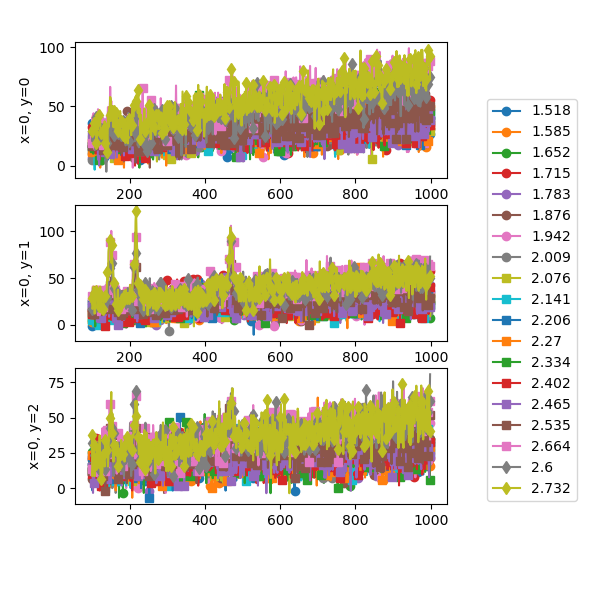

interactive(children=(IntSlider(value=0, description='seg_id', max=6), IntSlider(value=0, description='x', max…

(<Figure size 600x600 with 3 Axes>,
 array([<Axes: ylabel='x=0, y=0'>, <Axes: ylabel='x=0, y=1'>,
        <Axes: ylabel='x=0, y=2'>], dtype=object))

In [14]:
data["charge1"].cosmic_ray_view()

In [15]:
discharge1_CREs = {'voltage': [1.675, 1.739, 1.933, 1.933, 2.064],
 'x_pos': [1, 15, 1, 0, 12],
 'y_pos': [19, 17, 4, 13, 18],
 'spike_pos': [806, 856, 651, 719, 179],
 'smooth_width': [5, 5, 5, 5, 5]}

charge1_CREs = {'voltage': [2.141, 2.535, 2.535, 2.009, 2.732, 2.206, 2.076],
 'x_pos': [2, 1, 6, 7, 7, 1, 0],
 'y_pos': [0, 8, 8, 16, 17, 16, 16],
 'spike_pos': [522, 221, 1000, 345, 366, 900, 456],
 'smooth_width': [5, 5, 5, 5, 5, 5, 5]}

In [17]:
if "example_data" not in os.listdir(os.getcwd()):
    os.makedirs("example_data")
    
if "CRE_manual_selection" not in os.listdir("example_data"):
    os.makedirs(os.path.join("example_data", "CRE_manual_selection"))
np.save(os.path.join("example_data", "CRE_manual_selection", "discharge1.npy"), discharge1_CREs, allow_pickle=True)
np.save(os.path.join("example_data", "CRE_manual_selection", "charge1.npy"), charge1_CREs, allow_pickle=True)

In [57]:
dim_red = dict([(keys, SeriesDimensionReduction(values)) for keys, values in data.items()])

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

In [61]:
[values.perform_pca(n_components=10) for values in dim_red.values()];

<IPython.core.display.Javascript object>


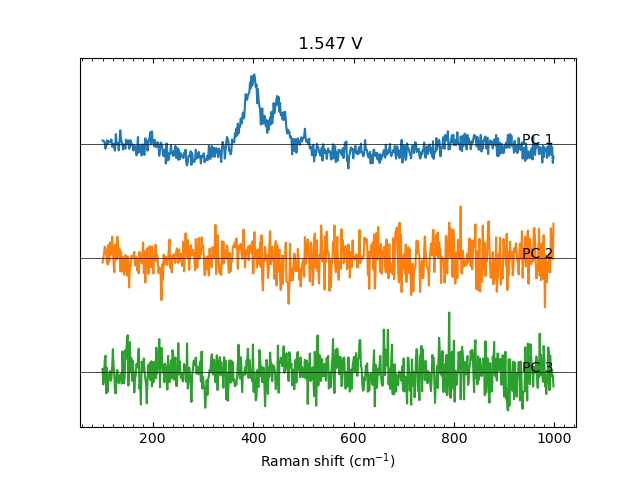

interactive(children=(IntSlider(value=0, description='v_idx', max=13), FloatSlider(value=0.3, description='off…

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': ' 1.547 V'}, xlabel='Raman shift (cm$^{-1}$)'>)

In [62]:
dim_red["discharge1"].visualise_components()

In [68]:
d1_pc1_sp = SelectPeaks(voltage_series=dim_red["discharge1"].voltage,
                        reload=os.path.join(os.path.dirname(data_path), "selected_peaks", "d1_pc1_sp.npy")
                       )

In [69]:
d1_pc1_sp.grid

In [70]:
d1_pc1_sp.get_checkbox_values(save_name="d1_pc1_sp", save_path=os.path.join(os.path.dirname(data_path),
                                                                            "selected_peaks"))

In [71]:
select_peaks_links = {"discharge1": "d1",
                      "charge1": "c1"}

In [72]:
for name in select_peaks_links.keys():
    print([fname for fname in os.listdir(os.path.join(os.path.dirname(data_path), "selected_peaks")) 
           if fname.split("_")[0]==select_peaks_links[name]])

['d1_pc1_sp.npy', 'd1_pc2_sp.npy']
['c1_pc1_sp.npy', 'c1_pc2_sp.npy']


In [74]:
select_peaks = dict([(name, [SelectPeaks(voltage_series=dim_red[name].voltage,
                                             reload=os.path.join(os.path.dirname(data_path), "selected_peaks", fname))
                            for fname in os.listdir(os.path.join(os.path.dirname(data_path), "selected_peaks")) if 
                             fname.split("_")[0]==select_peaks_links[name]])
                    for name in select_peaks_links.keys()])

[[sp_obj.get_checkbox_values() for sp_obj in values] for values in select_peaks.values()]

[[None, None], [None, None]]

In [77]:
fit_results = dict([(keys, FitResults(DimRed_object=values, SelectPeaks_objects=select_peaks[keys]))
                     for keys, values in dim_red.items() if keys in select_peaks.keys()])

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>


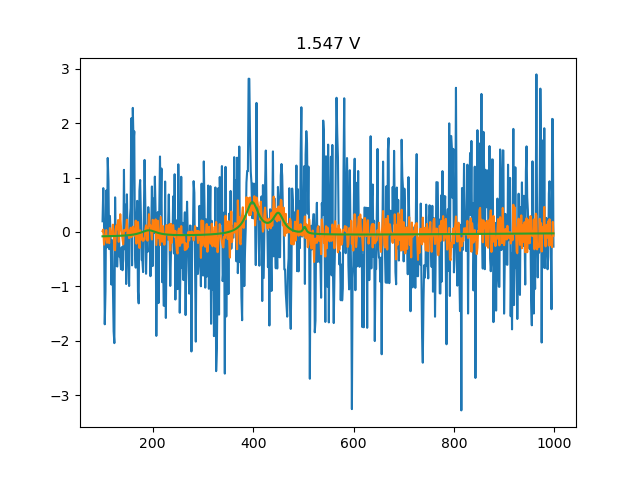

interactive(children=(IntSlider(value=0, description='x', max=20), IntSlider(value=0, description='y', max=20)…

(<Figure size 640x480 with 1 Axes>, <Axes: title={'center': '1.547 V'}>)

In [78]:
fit_results["discharge1"].plot_fit_results()

In [148]:
class _KNNpeaks(object):
    def __init__(knn_self, self, cycle, x_component=0, y_component=1, n_neighbours=3, random_seed=0, n_training_spectra=100):
        import random
        from sklearn.decomposition import PCA
        
        knn_self._cycle = cycle
        knn_self.x_component = x_component
        knn_self.y_component = y_component
        knn_self.x_extent = self.dim_red[cycle].common.x_extent
        knn_self.y_extent = self.dim_red[cycle].common.y_extent
        knn_self.data_extent = self.dim_red[cycle].common.x_extent*self.dim_red[cycle].common.y_extent
        
        knn_self.n_training_spectra = n_training_spectra
        knn_self.n_neighbours = n_neighbours
       ### knn_self.merged = np.vstack((self.dim_red[cycle].normalised.values()))
        norm_data_3darray = np.array([*sample.dim_red[cycle].normalised.values()])
        knn_self.merged = norm_data_3darray.reshape((len(sample.dim_red[cycle].normalised)*sample.raw_data[cycle].common.x_extent*sample.raw_data[cycle].common.y_extent,
                           sample.raw_data[cycle].common.shift_extent))
        
        
        knn_self.pca = PCA()
        knn_self.fit_transformed = knn_self.pca.fit_transform(knn_self.merged)
        knn_self.components = knn_self.pca.components_
        
        random.seed(random_seed)
        knn_self.spectra_list = []
        while len(knn_self.spectra_list) < n_training_spectra:
            new_number = int(knn_self.merged.shape[0]*random.random())
            if new_number not in knn_self.spectra_list:
                knn_self.spectra_list.append(new_number)
            else:
                continue
                
        knn_self._ft = knn_self.fit_transformed
        
        knn_self.features = np.array([[knn_self._ft[idx, knn_self.x_component],
                                       knn_self._ft[idx, knn_self.y_component]] for idx in knn_self.spectra_list])
        
        knn_self.label_lists = {}
        
        knn_self._outer_self = self
        
        
    def peak_select_viewer(knn_self):
        self = knn_self._outer_self
        cycle = knn_self._cycle
        from ipywidgets import interact, IntSlider
        f, (axes) = plt.subplots(1, 2, figsize=(10, 4))
        axes[1].plot(knn_self.fit_transformed[:, knn_self.x_component],
                    knn_self.fit_transformed[:, knn_self.y_component], "o")
        marker, = axes[1].plot([], [], "o")

        def update(idx):
            i = knn_self.spectra_list[idx]
#             axes[1].set_title(knn_self.fit_transformed[i, knn_self.x_component])
            marker.set_xdata([knn_self.fit_transformed[i, knn_self.x_component]])
            marker.set_ydata([knn_self.fit_transformed[i, knn_self.y_component]])

            axes[0].cla()
            axes[0].plot(self.dim_red[cycle].common.shift, 
                         knn_self.merged[i])

        interact(update, idx=IntSlider(min=0, max=knn_self.n_training_spectra-1, step=1))
        
    def fit_model(knn_self, label_key):
        from sklearn.neighbors import KNeighborsClassifier
        self = knn_self._outer_self
        
        labels = np.zeros((knn_self.n_training_spectra))
        for idx in knn_self.label_lists[label_key]:
            labels[idx] = 1
        model = KNeighborsClassifier(n_neighbors=knn_self.n_neighbours)
        
        model.fit(knn_self.features, labels)
        
        test_data = [knn_self._ft[idx, [knn_self.x_component, knn_self.y_component]] for idx in range(knn_self._ft.shape[0]) if idx not in knn_self.spectra_list]
        
        test_predict = model.predict(test_data)
        
        ### Why is this necessary?! - need to check why not just
        ## [n for n in np.arange(knn_self.merged.shape[0]) if n not in knn_self.spectra_list]
        all_idx = np.arange(knn_self.merged.shape[0], dtype=float)
        for n in range(all_idx.shape[0]):
            if all_idx[n] in knn_self.spectra_list:
                all_idx[n] = np.nan
        test_idx = [int(n) for n in all_idx if np.isfinite(n)]
        
        merged_predict = np.full((knn_self.merged.shape[0]), np.nan)
        for n, idx in enumerate(knn_self.spectra_list):
            merged_predict[idx] = labels[n]
        for n, idx in enumerate(test_idx):
            merged_predict[idx] = test_predict[n]
        knn_self.predict_dict = dict([(voltage,
                                   merged_predict[n*knn_self.data_extent:(n+1)*knn_self.data_extent].reshape(knn_self.x_extent, knn_self.y_extent))
                                 for n, voltage in enumerate(self.dim_red[knn_self._cycle].voltage)])
        
    def check_fit(knn_self):
        present = np.vstack(([values.flatten() for values in knn_self.predict_dict.values()])).flatten()
        f, ax = plt.subplots()
        ax.plot(knn_self.fit_transformed[:, knn_self.x_component],
                    knn_self.fit_transformed[:, knn_self.y_component], "o")
        ax.plot(knn_self.fit_transformed[np.argwhere(present==1), knn_self.x_component],
                    knn_self.fit_transformed[np.argwhere(present==1), knn_self.y_component], "o")
        return f, ax
    
  

In [149]:
class CellData(object):
    def __init__(self, sample_path, defaults=True, fit_results=True):
        """
        Methods
        ----------
        two_pass_fit(cycle, center_tolerance=10, sigma_max=50, verbose=True)
        
        one_pass_fit(cycle, peaks_1PF=None, center_tolerance=10, sigma_max=50, verbose=True)
        """
        
        self.sample_path = sample_path
        
        ## Added 21/01/2023 for compatibility with additional plotting functions
        self.peak_dict = {218: "S$_{8}$",
                 202: "S$_{4}^{2-}$",
                 398: "I(398)",##"S$_{6, 8}^{2-}$",
                 450: "I(450)", ##"S$_{4, 2}^{2-}$",
                 504: "S$_{6}^{2-}$"}
        
        self.raw_data = dict([(cycle_label, MapSeries(os.path.join(sample_path, "RawData", cycle_label))) 
                                for cycle_label in os.listdir(os.path.join(sample_path, "RawData")) if "charge" in cycle_label])
        
        if defaults == True:
            try:
                self.CRE = dict([(cycle_label.strip(".npy"), 
                     np.load(os.path.join(sample_path, "CRE_manual_selection", cycle_label), allow_pickle=True).item())
                    for cycle_label in os.listdir(os.path.join(sample_path, "CRE_manual_selection")) if "charge" in cycle_label])

                for cycle_label, CRE_values in self.CRE.items():
                    for n in range(len(CRE_values["voltage"])):
                        self.raw_data[cycle_label].data[CRE_values["voltage"][n]].fix_cosmic_ray(x_pos=CRE_values["x_pos"][n],
                                                                                            y_pos=CRE_values["y_pos"][n],
                                                                                            spike_pos=CRE_values["spike_pos"][n],
                                                                                            smooth_width=CRE_values["smooth_width"][n])
            except:
                pass
            [map_series.set_clip_range(100, 1000) for map_series in self.raw_data.values()];
            
        
            for cycle_label in self.raw_data.keys():
                if os.path.isdir(os.path.join(sample_path, "processed_data", cycle_label)) == False:
                    os.makedirs(os.path.join(sample_path, "processed_data", cycle_label))
                    
            self.dim_red = dict([(cycle_label, SeriesDimensionReduction(self.raw_data[cycle_label], reload_path=os.path.join(sample_path, "processed_data", cycle_label)))
                             for cycle_label in self.raw_data.keys()])
            
            [dim_red_values.perform_pca(10) for dim_red_values in self.dim_red.values()];
            
            self.peak_selections = {}

            if fit_results==True:
                for peak_file in os.listdir(os.path.join(sample_path, "selected_peaks")):
                    try:
                        cycle_label = peak_file.split("_")[0]
                        if "c" in cycle_label:
                            cycle_type = "charge"
                        else:
                            cycle_type = "discharge"
## Ammended 18.08.2022: changed re.findall("\d", cycle_label)[0] to re.findall("\d+", cycle_label)[0]
                        cycle_number = re.findall("\d+", cycle_label)[0]
                        selection = SelectPeaks(self.raw_data[cycle_type+cycle_number].voltage,
                                                    reload=os.path.join(sample_path, "selected_peaks", peak_file))
                        selection.get_checkbox_values()

                        if cycle_type+cycle_number in self.peak_selections.keys():
                            self.peak_selections[cycle_type+cycle_number].append(selection)
                        else:
                            self.peak_selections.update([(cycle_type+cycle_number, [selection])])
                    except:
                        pass
                
                self.fit_results = dict([(cycle_label,
                     FitResults(self.dim_red[cycle_label], SelectPeaks_objects=self.peak_selections[cycle_label]))
                    for cycle_label in self.peak_selections])
                
        class _KNN_container(object):
            def __init__(container_self):
                pass
        
        self.KNN = _KNN_container()
        
   ### CHANGED 12/11/2022
   ### CHANGED 20/11/2022
    
    def two_pass_fit(self, cycle, center_tolerance=10, sigma_max=50, verbose=True):
        x_extent = self.dim_red[cycle].common.x_extent
        y_extent = self.dim_red[cycle].common.y_extent
        shift_extent = self.dim_red[cycle].common.shift_extent
        grid_ref = np.arange(x_extent*y_extent).reshape(x_extent, y_extent)
        
        def _2_pass_pos(x, y, spectrum_fit_arr, values_fit, time_to_fit):
            start_time = datetime.now()
            model = LinearModel()


            neg_idx = np.nonzero(np.sign(self.dim_red[cycle].normalised[voltage][grid_ref[x, y]])==-1)
            negatives = self.dim_red[cycle].normalised[voltage][grid_ref[x, y]][neg_idx]

            all_peaks_to_fit = np.unique([item for sublist in [*self.fit_results[cycle].peaks_to_fit[voltage].values()] for item in sublist])
            positive_peaks = []

            for peak in all_peaks_to_fit:
                if self.fit_results[cycle].scaled_results[peak][voltage][x, y] > -0.5*np.nanmedian(negatives):
                    model += LorentzianModel(prefix="peak_{}_".format(peak))
                    params = model.make_params()
                    positive_peaks.append(peak)

            try:
                for peak in positive_peaks:
                    peak_sigma = np.nanmedian(([self.fit_results[cycle].fit_results[voltage][keys].best_values["peak_{}_sigma".format(peak)] 
                                                for keys, values in self.fit_results[cycle].peaks_to_fit[voltage].items() 
                                                if peak in values]))

                    for name in params:
                        if name not in ["intercept", "slope"]:
                            center = int(name.split("_")[1])
                            if "center" in name and str(peak) in name:
                                params[name].value = center
                                params[name].min = center-center_tolerance
                                params[name].max = center+center_tolerance
                            if "sigma" in name and str(peak) in name:
                                params[name].min = 1
                                params[name].max = sigma_max
                                params[name].value = peak_sigma
                            if "amplitude" in name and str(peak) in name:
                                params[name].value = self.fit_results[cycle].scaled_results[peak][voltage][x, y]*np.pi*peak_sigma   
                                params[name].min = 0

                fit_result = model.fit(x=self.dim_red[cycle].common.shift,
                         data=self.dim_red[cycle].normalised[voltage][grid_ref[x, y]],
                          params=params)
                end_time = datetime.now()

                spectrum_fit_arr[x, y, :] = fit_result.best_fit

                for peak in positive_peaks:
                    if peak not in values_fit.keys():
                        values_fit.update([(peak, {"center": np.full((x_extent, y_extent), np.nan),
                                                   "sigma": np.full((x_extent, y_extent), np.nan),
                                                   "amplitude": np.full((x_extent, y_extent), np.nan)})])
                    for parameter in ["center", "sigma", "amplitude"]:
                        values_fit[peak][parameter][x, y] = fit_result.best_values["peak_{}_{}".format(peak, parameter)]
                time_to_fit[x, y] = (end_time-start_time).microseconds
            except:
                pass
            
        
        for voltage in self.dim_red[cycle].voltage:
            if verbose == True:
                print(voltage)

            save_path_2PF = os.path.join(self.sample_path, "2_pass_fit", cycle, str(voltage))
            if os.path.isdir(save_path_2PF) == False:
                os.makedirs(save_path_2PF)

                spectrum_fit_arr = np.full((x_extent, y_extent, shift_extent), np.nan)
                values_fit = {}
                time_to_fit = np.full((x_extent, y_extent), np.nan, dtype=float)

                if verbose == True:
                    for x in notebook(range(x_extent)):
                        for y in range(y_extent):
                             _2_pass_pos(x, y, spectrum_fit_arr, values_fit, time_to_fit)
                else:
                    for x in range(x_extent):
                        for y in range(y_extent):
                            _2_pass_pos(x, y, spectrum_fit_arr, values_fit, time_to_fit)

                np.save(os.path.join(save_path_2PF, "fitted_spectra.npy"), spectrum_fit_arr, allow_pickle=True)
                np.save(os.path.join(save_path_2PF, "fitted_lorentzian_params.npy"), values_fit, allow_pickle=True)
                np.save(os.path.join(save_path_2PF, "time_to_fit.npy"), time_to_fit, allow_pickle=True)
        
        setattr(self, cycle, _TwoPass(self=self, cycle=cycle))
        
    def one_pass_fit(self, cycle, peaks_1PF=None, center_tolerance=10, sigma_max=50, verbose=True): 
        x_extent = self.dim_red[cycle].common.x_extent
        y_extent = self.dim_red[cycle].common.y_extent
        shift_extent = self.dim_red[cycle].common.shift_extent
        shift = self.dim_red[cycle].common.shift
        grid_ref = np.arange(x_extent*y_extent).reshape(x_extent, y_extent)
        
        
        for voltage in self.dim_red[cycle].voltage[::-1]:
            if verbose == True:
                print(voltage)
                
            if peaks_1PF == None:
                peaks_1PF = [152, 202, 218, 248, 398, 438, 450, 473, 504]
            save_path_1PF = os.path.join(self.sample_path, "1_pass_fit", cycle, str(voltage))
            if os.path.isdir(save_path_1PF) == False:
                os.makedirs(save_path_1PF)

                spectra_1PF = np.full((x_extent, y_extent, shift_extent), np.nan)
                values_1PF = dict([(peak, {"center": np.full((x_extent, y_extent), np.nan),
                                           "sigma": np.full((x_extent, y_extent), np.nan),
                                           "amplitude": np.full((x_extent, y_extent), np.nan)})
                                  for peak in peaks_1PF])
                time_to_fit_1PF = np.full((x_extent, y_extent), np.nan, dtype=float)

                model_1PF = LinearModel()
                for peak in peaks_1PF:
                    model_1PF += LorentzianModel(prefix="peak_{}_".format(peak))

                for x in notebook(range(x_extent)):
                    for y in notebook(range(y_extent)):
                        start_time = datetime.now()

                        params_1PF = model_1PF.make_params()
                        for name in params_1PF:
                            if name not in ["intercept", "slope"]:
                                center = int(name.split("_")[1])
                                if "center" in name:
                                    params_1PF[name].value = center
                                    params_1PF[name].min = center-center_tolerance
                                    params_1PF[name].max = center+center_tolerance
                                if "sigma" in name:
                                    params_1PF[name].min = 1
                                    params_1PF[name].max = sigma_max
                                    params_1PF[name].value = 2
                                if "amplitude" in name:
                                    params_1PF[name].min = 0

                        model_fit_1PF = model_1PF.fit(x=shift, 
                                      data=self.dim_red[cycle].normalised[voltage][grid_ref[x, y]],
                                      params=params_1PF)
                        spectra_1PF[x, y, :] = model_fit_1PF.best_fit
                        for peak in peaks_1PF:
                            for name in ["center", "sigma", "amplitude"]:
                                values_1PF[peak][name][x, y] = model_fit_1PF.best_values["peak_{}_{}".format(peak, name)]

                        end_time = datetime.now()
                        time_to_fit_1PF[x, y] = (end_time-start_time).microseconds

                np.save(os.path.join(save_path_1PF, "fitted_spectra.npy"), spectra_1PF, allow_pickle=True)
                np.save(os.path.join(save_path_1PF, "fitted_lorentzian_params.npy"), values_1PF, allow_pickle=True)
                np.save(os.path.join(save_path_1PF, "time_to_fit.npy"), time_to_fit_1PF, allow_pickle=True)
        
    def knn_select(self, cycle, x_component=0, y_component=1, n_neighbours=3, random_seed=0, n_training_spectra=100):
        setattr(self.KNN, cycle, _KNNpeaks(self=self, cycle=cycle, x_component=x_component,
                                           y_component=y_component, random_seed=random_seed, n_training_spectra=n_training_spectra))
        
        
#### ADDITIONS JAN 2023
    def make_intensities(self, cycle):
        all_peaks = np.unique(np.hstack([[*voltage_values.keys()] for voltage_values in vars(self)[cycle].values.values()]))
        x_extent = self.raw_data[cycle].common.x_extent
        y_extent = self.raw_data[cycle].common.y_extent

        intensities = {}
        for voltage, voltage_values in vars(self)[cycle].values.items():
            intensities.update([(voltage, {})])
            for peak in all_peaks:
                if peak in voltage_values.keys():
                    intensities[voltage].update([(peak,
                                                  voltage_values[peak]["amplitude"]/voltage_values[peak]["sigma"]/np.pi)])
                else:
                    intensities[voltage].update([(peak, np.full((x_extent, y_extent), np.nan))])

        return intensities

    def make_bplot_intensities(self, cycle, peak, predict_dict, discharge=True):
        intensity_data = self.make_intensities(cycle)
               
        if discharge==True:
            voltages = np.sort([*intensity_data.keys()])[::-1]
        else:
            voltages = np.sort([*intensity_data.keys()])

        bp_i = dict([(peak, dict([(voltage, np.array([])) 
                                  for voltage in voltages]))])

        for voltage in voltages:
            if peak in np.sort([*intensity_data[voltage].keys()])[::-1]:
                try:
                    bp_i[peak][voltage] = intensity_data[voltage][peak][predict_dict[voltage]==1][
                                np.isfinite(intensity_data[voltage][peak][predict_dict[voltage]==1])
                    ]
                except:
                    bp_i[peak][voltage] = np.array([])
        return bp_i
    
    def PS_peak_scatter(self, cycle, predict_dict, discharge=True, peak_plots=[398, 450], voltage_cutoff=2.1):

        all_peaks = np.unique(np.hstack([[*voltage_values.keys()] for voltage_values in vars(self)[cycle].values.values()]))
        x_extent = self.raw_data[cycle].common.x_extent
        y_extent = self.raw_data[cycle].common.y_extent

        intensities = self.make_intensities(cycle)

        intensity_filtered = dict([(voltage, intensities[voltage][peak_plots[0]][predict_dict[voltage]==1])
                                    for voltage in intensities if peak_plots[0] in intensities[voltage].keys()
                                    and intensities[voltage][peak_plots[0]][predict_dict[voltage]==1].shape[0]>0])

        voltage = intensity_filtered.keys()
        if voltage_cutoff != None:
            lower_peak = [v for v in voltage if v<voltage_cutoff]
            upper_peak = [v for v in voltage if v>=voltage_cutoff]

            upper_colors = [plt.cm.Reds_r(i) for i in np.linspace(0.2, 0.8, len(upper_peak))]
            lower_colors = [plt.cm.Blues_r(i) for i in np.linspace(0.2, 0.8, len(lower_peak))]

            colors = upper_colors+lower_colors
        else:
            colors = [plt.cm.viridis(i) for i in np.linspace(0, 1, len(voltage))]

        markers = ["o", "s", "^", "v"]

        vmax = percentile_vmax(np.hstack((values[peak].flatten() for values in intensities.values()
                                              for peak in values.keys() if peak in peak_plots)))

        f, ax = plt.subplots()

        ax.set_prop_cycle("marker", markers)

        for nvolt, voltage in enumerate([*intensity_filtered.keys()][::-1]):
            ax.plot(intensities[voltage][peak_plots[0]][predict_dict[voltage]==1],
                        intensities[voltage][peak_plots[1]][predict_dict[voltage]==1],
                        label=voltage, color=colors[nvolt], ls="none")

        ax.set_xlabel("{} (a.u.)".format(self.peak_dict[peak_plots[0]]))
        ax.set_ylabel("{} (a.u.)".format(self.peak_dict[peak_plots[1]]))

        x_min = ax.get_xlim()
        y_min = ax.get_ylim()
        ax.plot([x_min[0], x_min[1]], [y_min[0], y_min[1]],
                color="k", zorder=0, marker=None, lw=0.5)
        ax.set_xlim(x_min)
        ax.set_ylim(y_min)
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
        ax.set_aspect("equal")

        return f, ax        
    
    def heatmaps(self, cycle, discharge=True, peaks_to_plot=[218, 202, 398, 450, 504], voltages_to_plot="all", titles=None):
        
        if titles == None:
            titles = ["I({})".format(peak) for peak in peaks_to_plot]
            

        
        all_peaks = np.unique(np.hstack([[*voltage_values.keys()] for voltage_values in vars(self)[cycle].values.values()]))
        x_extent = self.raw_data[cycle].common.x_extent
        y_extent = self.raw_data[cycle].common.y_extent
        intensities = self.make_intensities(cycle)
        
        if voltages_to_plot=="all":
            voltages = [*intensities.keys()]
        else:
            voltages = voltages_to_plot
            
        if discharge == True:
            voltages = np.sort(list(voltages))[::-1]
        else:
            voltages = np.sort(list(voltages))
                
                
        vmax = percentile_vmax(np.hstack((values[peak].flatten() for values in intensities.values()
                                              for peak in values.keys() if peak in peaks_to_plot)))

        f, (axes) = plt.subplots(len(voltages), len(peaks_to_plot),
                                 figsize=(len(peaks_to_plot), len(voltages)))
        for npeak, peak in enumerate(peaks_to_plot):
            axes[0, npeak].set_title(titles[npeak])
            for nvolt, volt in enumerate(voltages):
                axes[nvolt, 0].set_ylabel("{} V".format(volt))
                axes[nvolt, npeak].set_xticks([])
                axes[nvolt, npeak].set_yticks([])
                try:
                    axes[nvolt, npeak].imshow(intensities[volt][peak], vmin=0, vmax=vmax, cmap="YlOrRd")
                except:
                    axes[nvolt, npeak].imshow(np.full((x_extent, y_extent), np.nan))   

        return f, axes    

    

In [150]:
sample = CellData(os.path.join(os.path.dirname(data_path)))

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

In [151]:
sample.one_pass_fit("discharge1")

2.39
2.326
2.259
2.195
2.131
2.064
2.0
1.933
1.868
1.803
1.739
1.675
1.611
1.547


In [152]:
sample.two_pass_fit("discharge1")

1.547
1.611
1.675
1.739
1.803
1.868
1.933
2.0
2.064
2.131
2.195
2.259
2.326
2.39


In [153]:
sample.knn_select("discharge1", n_training_spectra=200)

<IPython.core.display.Javascript object>


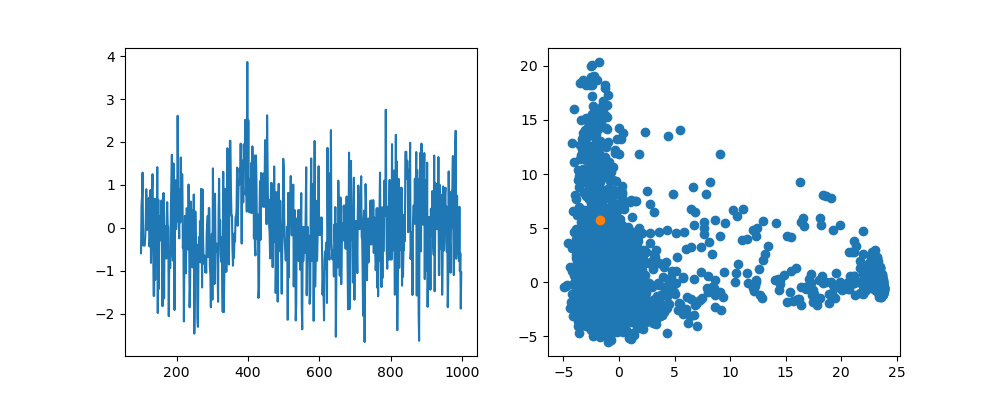

interactive(children=(IntSlider(value=0, description='idx', max=199), Output()), _dom_classes=('widget-interac…

In [154]:
sample.KNN.discharge1.peak_select_viewer()

In [155]:
sample.KNN.discharge1.label_lists.update([("sulfur", [16, 21, 29, 38, 85, 108, 111, 119, 122, 142, 155, 160, 181])])
sample.KNN.discharge1.label_lists.update([("PS_weak", [12, 13, 26, 146, 176, 190, 196, ])])
sample.KNN.discharge1.label_lists.update([("PS", [36, 101, 125])])
sample.KNN.discharge1.label_lists.update([("mixed", [155, 181, ])])

In [156]:
sample.KNN.discharge1.fit_model("sulfur")
sulfur_predict_d1 = sample.KNN.discharge1.predict_dict

<IPython.core.display.Javascript object>


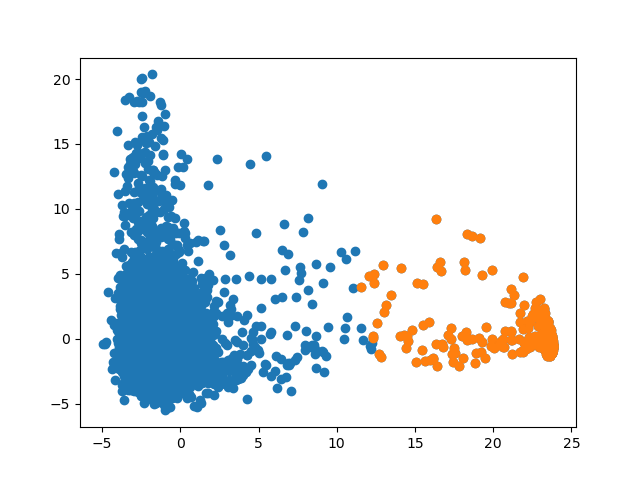

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [157]:
sample.KNN.discharge1.check_fit()

In [158]:
sample.KNN.discharge1.fit_model("PS")
PS_predict_d1 = sample.KNN.discharge1.predict_dict

sample.KNN.discharge1.fit_model("mixed")
mixed_predict_d1 = sample.KNN.discharge1.predict_dict

all_peaks =np.unique(np.hstack([[*voltage_values.keys()] for voltage_values in sample.discharge1.values.values()]))

In [159]:
d1_intensities = dict([(voltage, 
                     dict([(peak, peak_vals["amplitude"]/np.pi/peak_vals["sigma"])
                           for peak, peak_vals in voltage_vals.items()]))
                     for voltage, voltage_vals in sample.discharge1.values.items()])

In [160]:
x_extent = sample.dim_red["discharge1"].common.x_extent
y_extent = sample.dim_red["discharge1"].common.y_extent
shift_extent = sample.dim_red["discharge1"].common.shift_extent




volt_max = 2.8
volt_min = 1.5
peak_plots = [218, 398, 450]

for peak in peak_plots:
    for voltage in sulfur_predict_d1.keys():
        if peak not in d1_intensities[voltage].keys():
            d1_intensities[voltage].update([(peak, np.full((x_extent, y_extent), np.nan))])

In [170]:
cv = CycVolt(os.path.join(os.path.dirname(data_path), "electrochemistry", 
                          '25T_insitu_cGFc_200uL_1mm_3-1mg_211013_02_CV_C01.mpt'))

cv_full = mpt_to_df(os.path.join(os.path.dirname(data_path), "electrochemistry", 
                          '25T_insitu_cGFc_200uL_1mm_3-1mg_211013_02_CV_C01.mpt'))

def discharge_voltages(cycle, voltage_list):
    voltages = np.sort(voltage_list)[::-1]
    return (2*cycle-1)*(volt_max-volt_min)-(voltages-volt_min)

def charge_voltages(cycle, voltage_list):
    voltages = np.sort(voltage_list)
    return (2*cycle-1)*(volt_max-volt_min)+(voltages-volt_min)

In [190]:
cv.scan_rate

0.1

In [171]:
bp_volts = np.hstack((discharge_voltages(1, [*d1_intensities.keys()])))

In [172]:
min_step = np.nanmin(bp_volts[1:]-bp_volts[:-1])
offsets = np.linspace(-min_step/2, min_step/2, len(peak_plots)+2)[1:-1]
width = min_step/(len(peak_plots)+2)

In [173]:
color_dict = {218: plt.cm.Dark2(1),
              398: plt.cm.Dark2(0),
              450: plt.cm.Dark2(2)}

In [174]:
def make_intensities(intensity_data, predict_dict, discharge=True, peak_plots=[218, 398, 450]):
    
    if discharge==True:
        voltages = np.sort([*intensity_data.keys()])[::-1]
    else:
        voltages = np.sort([*intensity_data.keys()])
        
    bp_i = dict([(peak, dict([(voltage, np.full((x_extent, y_extent), np.nan)) 
                              for voltage in voltages]))
                for peak in peak_plots])
        
    for peak in peak_plots:
        for voltage in voltages:
            if peak in np.sort([*intensity_data[voltage].keys()])[::-1]:
                bp_i[peak][voltage] = intensity_data[voltage][peak][predict_dict[voltage]==1][
                                np.isfinite(intensity_data[voltage][peak][predict_dict[voltage]==1])
                ]
    return bp_i

In [175]:
bp_d1_i_s8 = make_intensities(d1_intensities, sulfur_predict_d1)


In [176]:
bp_d1_i = {218: bp_d1_i_s8[218],
           398: dict([(key, np.array([])) for key in bp_d1_i_s8[398].keys()]),
           450: dict([(key, np.array([])) for key in bp_d1_i_s8[450].keys()])}


In [177]:
voltage = np.array(cv_full["Ewe/V"])
current = np.array(cv_full["<I>/mA"])
dV = voltage[1:]-voltage[:-1]
cathodic = np.argwhere(np.sign(dV)==-1).flatten()
breakpoints = [c for nc, c in enumerate(cathodic[1:]) if cathodic[nc+1]-cathodic[nc] != 1 ]

In [178]:
lims_0 = [np.min(discharge_voltages(1, cv.discharge.voltage[0]))-0.1, 
          np.max(discharge_voltages(1, cv.discharge.voltage[0]))+0.1]
lims_1 = [np.min(discharge_voltages(3, cv.discharge.voltage[2]))-0.1,
          np.max(discharge_voltages(4, voltage[breakpoints[-1]:]))+0.1]

total_width = (lims_0[1]-lims_0[0])+(lims_1[1]-lims_1[0])

<IPython.core.display.Javascript object>


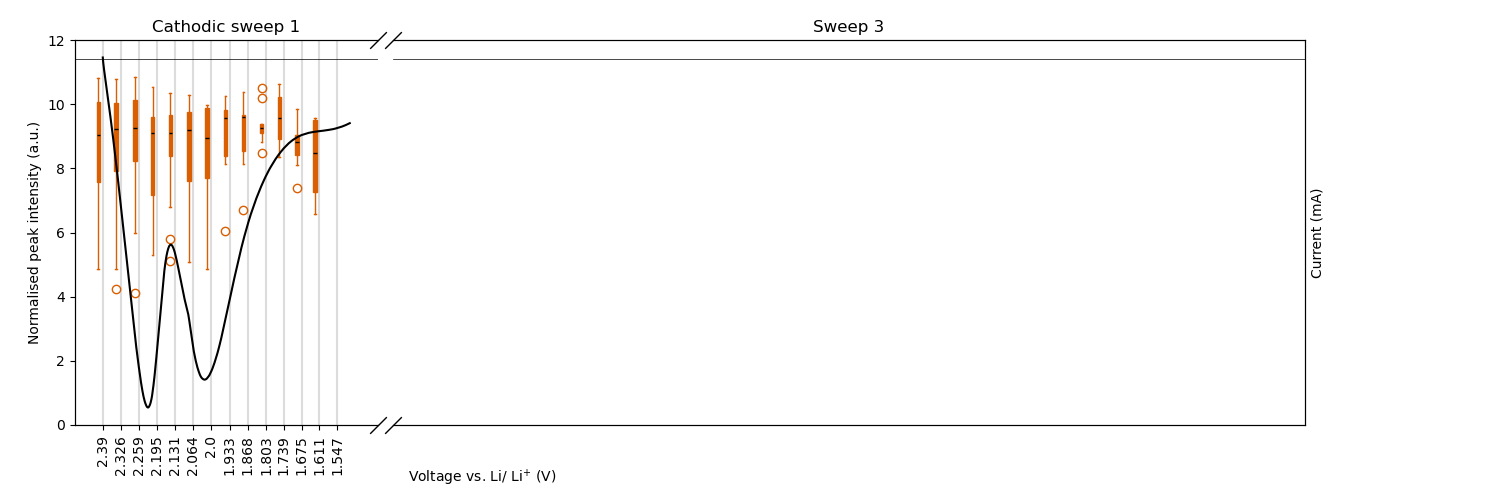

Text(0.5, 1.0, 'Sweep 3')

In [181]:
f, (axes_i) = plt.subplots(1, 2, figsize=(15, 5))
axes_cv = []
for ax in axes_i:
    axes_cv.append(ax.twinx())
axes_cv = np.array(axes_cv)

voltage_ticks = np.hstack((discharge_voltages(1, [*d1_intensities.keys()]),
                          ))

for i in range(2):
    bplot_dict_d1 = {}
    ax_i = axes_i[i]
    ax_cv = axes_cv[i]
    
    for npeak, peak in enumerate(peak_plots):
        bplot_dict_d1.update([(peak, ax_i.boxplot([*bp_d1_i[peak].values()],
                  positions=discharge_voltages(1, [*d1_intensities.keys()])+offsets[npeak],
                    widths=width,
                  patch_artist=True))])
    
    for bplot in [bplot_dict_d1]:
        for npeak, peak in enumerate(peak_plots):
            for box in bplot[peak]["boxes"]:
                box.set_facecolor(color_dict[peak])
                box.set_edgecolor(color_dict[peak])
            for line in bplot[peak]["medians"]:
                line.set_color("black")
            for line in bplot[peak]["fliers"]:
                line.set_markeredgecolor(color_dict[peak])
            for line in bplot[peak]["whiskers"]:
                line.set_color(color_dict[peak])
            for line in bplot[peak]["caps"]:
                line.set_color(color_dict[peak])
    ax_cv.plot(discharge_voltages(1, cv.discharge.voltage[0]), cv.discharge.current[0], color="k")
    ax_cv.axhline(0, color="k", lw=0.5)
    
    ax_i.set_xticks(voltage_ticks)
    x_label = np.hstack((np.sort([*d1_intensities.keys()])[::-1],
                        ))
    ax_i.set_xticklabels(x_label, rotation=90);
    ax_i.set_ylim([0, 12])
    [ax_i.axvline(m, color="gainsboro", zorder=0) for m in voltage_ticks]
#     [ax_i.axvline(m+min_step/2, color="blue") for m in voltage_ticks]


axes_i[0].set_xlim(lims_0)
axes_i[1].set_xlim(lims_1)
# axes_i[2].set_xlim(lims_2)

pos_0 = axes_i[0].get_position()
margin = 0.01

width_scaler = 0.8

axes_i[0].set_position((0.05, 0.15,
                    width_scaler*(lims_0[1]-lims_0[0])/total_width, 
                    pos_0.height))
pos_0 = axes_i[0].get_position()
axes_i[1].set_position((pos_0.x0+width_scaler*(lims_0[1]-lims_0[0])/total_width+margin,
                    pos_0.y0, 
                    width_scaler*(lims_1[1]-lims_1[0])/total_width+margin, pos_0.height))
# axes_i[2].set_position((pos_0.x0+(width_scaler*(lims_0[1]-lims_0[0])/total_width+margin)+\
#                     (width_scaler*(lims_1[1]-lims_1[0])/total_width+margin)+margin,
#                     pos_0.y0,
#                     (width_scaler*(lims_2[1]-lims_2[0])/total_width),
#                     pos_0.height))

for ax in [axes_i[0], axes_cv[0]]:
    ax.spines["right"].set_visible(False)
    ax.tick_params(which="both", right=False)
    
axes_cv[0].set_yticks([])
    
for ax in [axes_i[1], axes_cv[1]]:
    ax.spines["left"].set_visible(False)
#     ax.spines["right"].set_visible(False)
    ax.tick_params(which="both", right=False, left=False)
    ax.set_yticks([])
    
# for ax in [axes_i[2], axes_cv[2]]:
#     ax.spines["left"].set_visible(False)
#     ax.tick_params(which="both", left=False)
# axes_i[2].set_yticks([])

length = 1  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -length), (1, length)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
axes_i[0].plot([1, 1], [1, 0], transform=axes_i[0].transAxes, **kwargs)
axes_i[1].plot([0, 0], [0, 1], transform=axes_i[1].transAxes, **kwargs)
# axes_i[1].plot([0, 0, 1, 1], [1, 0, 0, 1], transform=axes_i[1].transAxes, **kwargs)
# axes_i[2].plot([0, 0], [0, 1], transform=axes_i[2].transAxes, **kwargs)

axes_i[0].set_ylabel("Normalised peak intensity (a.u.)")
axes_cv[-1].set_ylabel("Current (mA)")

axes_i[0].text(x=1.1, y=-0.15, s="Voltage vs. Li/ Li$^{+}$ (V)", transform=axes_i[0].transAxes)

axes_i[0].set_title("Cathodic sweep 1")
axes_i[1].set_title("Sweep 3")
